<a href="https://colab.research.google.com/github/LakshmiAhala/MachineLearning/blob/main/ML_Assign12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [72]:
#@title Necessary Imports

from sklearn.datasets import load_breast_cancer
from sklearn.datasets import load_iris
from sklearn.model_selection import (
    cross_val_score,      # Function to perform cross-validation
    KFold,                # K-Fold CV
    StratifiedKFold,      # Stratified K-Fold CV
    LeaveOneOut,          # Leave-One-Out CV
    LeavePOut,            # Leave-P-Out CV
    TimeSeriesSplit       # Time Series CV
)
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt

#Step 1: Select a Classification Dataset

In [73]:
#@title Basic Information

# Loading and Splitting dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Dataset Information
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of classes: {len(set(y))}")

# Data split
print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

Number of samples: 569
Number of features: 30
Number of classes: 2
Shape of features (X): (569, 30)
Shape of target (y): (569,)


# Step 2: Build a Decision Tree Classifier

In [74]:
#@title Creating the model

model = DecisionTreeClassifier(random_state=42)
print(model)

DecisionTreeClassifier(random_state=42)


#Step 3: Apply K-Fold Cross Validation

In [75]:
#@title Cross Validation

k_values = range(2, 11)
mean_accuracies = []

for k in k_values:
    # Using StratifiedKFold for classification tasks to preserve class proportions
    kf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')
    mean_accuracies.append(scores.mean())
    print(f"K = {k}: Mean Accuracy = {scores.mean():.4f}")

# Storing results in a dictionary for later visualization
cv_results = {
    'k_values': list(k_values),
    'mean_accuracies': mean_accuracies
}

print("\nCross-validation results stored in 'cv_results':")
print(cv_results)

K = 2: Mean Accuracy = 0.9157
K = 3: Mean Accuracy = 0.9332
K = 4: Mean Accuracy = 0.9103
K = 5: Mean Accuracy = 0.9104
K = 6: Mean Accuracy = 0.9174
K = 7: Mean Accuracy = 0.9121
K = 8: Mean Accuracy = 0.9209
K = 9: Mean Accuracy = 0.9226
K = 10: Mean Accuracy = 0.9262

Cross-validation results stored in 'cv_results':
{'k_values': [2, 3, 4, 5, 6, 7, 8, 9, 10], 'mean_accuracies': [np.float64(0.9156659253768223), np.float64(0.933249791144528), np.float64(0.9103097606618733), np.float64(0.9104021114733737), np.float64(0.9174132138857783), np.float64(0.9120531681507291), np.float64(0.9208969092331768), np.float64(0.9226466049382717), np.float64(0.9261904761904762)]}


#Step 4: Find the Optimal K

In [76]:
#@title Best K Value

# Finding the index of the highest mean accuracy
max_accuracy_index = mean_accuracies.index(max(mean_accuracies))

# Getting the corresponding K value and the maximum accuracy
best_k = k_values[max_accuracy_index]
highest_accuracy = mean_accuracies[max_accuracy_index]

print(f"The K value that gives the highest mean accuracy is K = {best_k} with a mean accuracy of {highest_accuracy:.4f}")

The K value that gives the highest mean accuracy is K = 3 with a mean accuracy of 0.9332


#Step 5: Create Visualizations

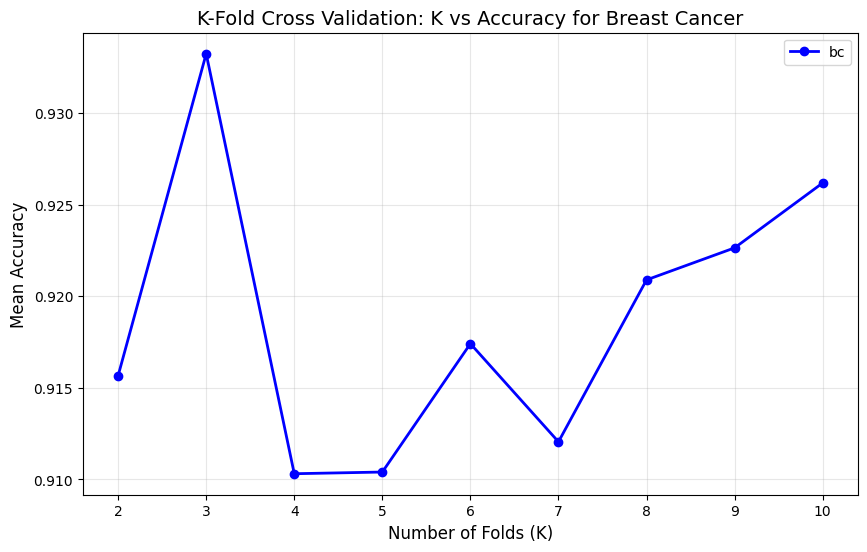

In [77]:
#@title Line Plot


# Creating the line plot for Iris only
plt.figure(figsize=(10, 6))
plt.plot(k_values, mean_accuracies, marker='o', linestyle='-', linewidth=2, color='blue', label='bc')

plt.xlabel('Number of Folds (K)', fontsize=12)
plt.ylabel('Mean Accuracy', fontsize=12)
plt.title('K-Fold Cross Validation: K vs Accuracy for Breast Cancer', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()



# BONUS - Comparison

## Compare Multiple Datasets (+1 point)

-- Run the same experiment on 2 different datasets
-- Compare which K works best for each dataset


Number of samples: 150
Number of features: 4
Number of classes: 3
Shape of features (X): (150, 4)
Shape of target (y): (150,)
DecisionTreeClassifier(random_state=42)
K = 2: Mean Accuracy = 0.9533
K = 3: Mean Accuracy = 0.9533
K = 4: Mean Accuracy = 0.9331
K = 5: Mean Accuracy = 0.9533
K = 6: Mean Accuracy = 0.9267
K = 7: Mean Accuracy = 0.9329
K = 8: Mean Accuracy = 0.9262
K = 9: Mean Accuracy = 0.9261
K = 10: Mean Accuracy = 0.9333

Cross-validation results stored in 'cv_results1':
{'k_values': [2, 3, 4, 5, 6, 7, 8, 9, 10], 'mean_accuracies': [np.float64(0.9533333333333334), np.float64(0.9533333333333333), np.float64(0.9331436699857752), np.float64(0.9533333333333335), np.float64(0.9266666666666666), np.float64(0.9329004329004329), np.float64(0.9261695906432748), np.float64(0.9260620915032679), np.float64(0.9333333333333333)]}
The K value that gives the highest mean accuracy for Iris is K = 5 with a mean accuracy of 0.9533


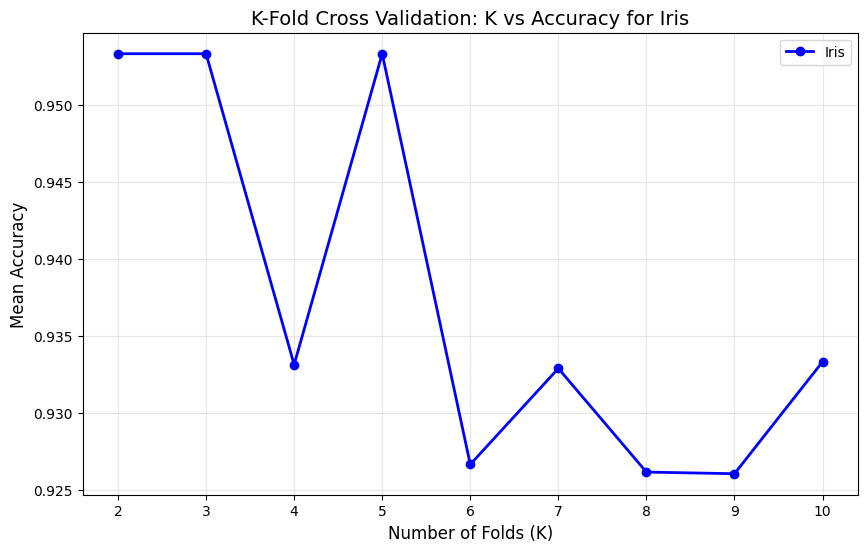

In [78]:
#@title Iris Dataset

# Loading and Splitting dataset
data1 = load_iris()
X1 = data1.data
y1 = data1.target

# Dataset Information
print(f"Number of samples: {X1.shape[0]}")
print(f"Number of features: {X1.shape[1]}")
print(f"Number of classes: {len(set(y1))}")

# Data split
print(f"Shape of features (X): {X1.shape}")
print(f"Shape of target (y): {y1.shape}")

# Building a decision tree
model1 = DecisionTreeClassifier(random_state=42)
print(model1)

k_values1 = range(2, 11)
mean_accuracies1 = []

for k_val in k_values1:
    # Using StratifiedKFold for classification tasks to preserve class proportions
    kf1 = StratifiedKFold(n_splits=k_val, shuffle=True, random_state=42)
    scores1 = cross_val_score(model1, X1, y1, cv=kf1, scoring='accuracy')
    mean_accuracies1.append(scores1.mean())
    print(f"K = {k_val}: Mean Accuracy = {scores1.mean():.4f}")

# Storing results in a dictionary for later visualization
cv_results1 = {
    'k_values': list(k_values1),
    'mean_accuracies': mean_accuracies1
}

print("\nCross-validation results stored in 'cv_results1':")
print(cv_results1)

# Finding the index of the highest mean accuracy
max_accuracy_index1 = mean_accuracies1.index(max(mean_accuracies1))

# Getting the corresponding K value and the maximum accuracy
best_k1 = k_values1[max_accuracy_index1]
highest_accuracy1 = mean_accuracies1[max_accuracy_index1]

print(f"The K value that gives the highest mean accuracy for Iris is K = {best_k1} with a mean accuracy of {highest_accuracy1:.4f}")

# Creating the line plot for Iris only
plt.figure(figsize=(10, 6))
plt.plot(k_values1, mean_accuracies1, marker='o', linestyle='-', linewidth=2, color='blue', label='Iris')

plt.xlabel('Number of Folds (K)', fontsize=12)
plt.ylabel('Mean Accuracy', fontsize=12)
plt.title('K-Fold Cross Validation: K vs Accuracy for Iris', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Combined Visualization of K-Fold Cross Validation for Both Datasets

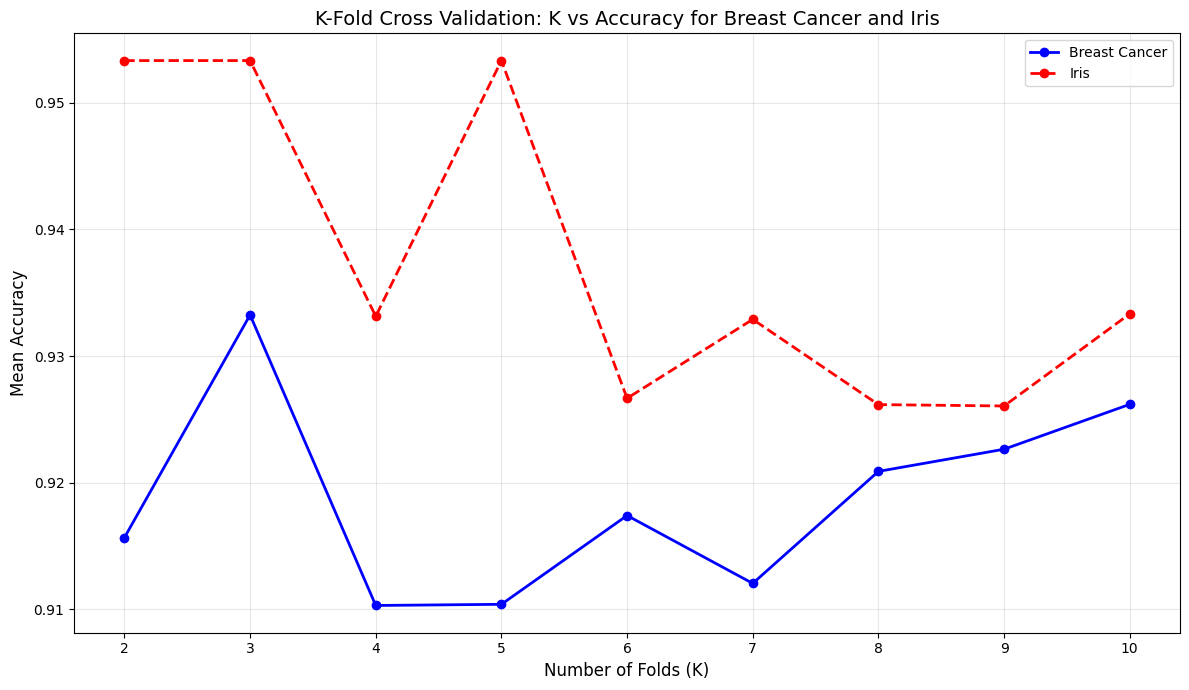

In [79]:
#@title Combined Line Plot

plt.figure(figsize=(12, 7))

# Plot for Breast Cancer dataset
plt.plot(cv_results['k_values'], cv_results['mean_accuracies'], marker='o', linestyle='-', linewidth=2, color='blue', label='Breast Cancer')

# Plot for Iris dataset
plt.plot(cv_results1['k_values'], cv_results1['mean_accuracies'], marker='o', linestyle='--', linewidth=2, color='red', label='Iris')

plt.xlabel('Number of Folds (K)', fontsize=12)
plt.ylabel('Mean Accuracy', fontsize=12)
plt.title('K-Fold Cross Validation: K vs Accuracy for Breast Cancer and Iris', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.xticks(list(range(2, 11))) # Ensure all K values are shown on x-axis
plt.tight_layout()
plt.show()

### Comparison of Optimal K-Mean Accuracies

In [80]:
#@title Compare Best K-Mean Accuracies

if highest_accuracy > highest_accuracy1:
    print(f"The Breast Cancer dataset had a better optimal K-mean accuracy: K = {best_k} with {highest_accuracy:.4f}")
elif highest_accuracy1 > highest_accuracy:
    print(f"The Iris dataset had a better optimal K-mean accuracy: K = {best_k1} with {highest_accuracy1:.4f}")
else:
    print("Both datasets achieved the same highest mean accuracy with their respective optimal K values.")

The Iris dataset had a better optimal K-mean accuracy: K = 5 with 0.9533
